[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/00_onboarding/00c_see_it_work.ipynb)

# 📓 Notebook 00c — See It Work: a 5-minute tour of what you'll build

> **You are here.** Optional but recommended *before* the Python foundations · ~5 minutes · just **run** the cells.

Most of this course is *you* building the pieces of an AI-driven automation. This notebook lets you **see the finished shapes first**, so the Python you learn next has an obvious destination. Everything here runs **offline** with a built-in mock AI — no API key, no internet, nothing to install.

> 🎯 **Don't read the code closely yet.** Watch the *outputs*. By the end of the course you'll write all of this yourself — and understand every line.

In [1]:
# Make the repo-root llm_providers.py importable regardless of the working directory.
import sys, pathlib
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "llm_providers.py").exists()), None)
if _root:                       # local checkout — use the repo's module
    sys.path.insert(0, str(_root))
else:                           # Colab / standalone — fetch it next to the notebook
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/ChrisW09/Python-for-AI-Driven-Automation"
        "/main/llm_providers.py", "llm_providers.py")

from llm_providers import MockLLM
llm = MockLLM(seed=42)
print("✅ Offline AI ready — no API key needed.")

✅ Offline AI ready — no API key needed.


## 1. An AI reads and triages customer feedback

Raw, free-form messages in → clean, structured tags out. This is the heart of an AI automation: turning messy text into something the rest of your code can act on.

*You'll build this for real in **Module 6 (NB 22 — AI workflows)** and ship it in **Capstone B (NB 42)**.*

In [2]:
import json

feedback = [
    "I love the new dashboard — it is fantastic and so fast!",
    "The login page is broken and frustrating; it keeps failing.",
    "Could you add a dark-mode feature? Would be nice to have.",
]

print("Customer feedback  →  structured tags")
print("-" * 60)
for msg in feedback:
    resp = llm.chat(messages=[
        {"role": "system", "content":
            "Classify the sentiment and topic of the message. "
            "Return JSON with keys 'sentiment' and 'topic'."},
        {"role": "user", "content": msg},
    ])
    tags = json.loads(resp["text"])
    print(f"  {tags['sentiment']:>8}  |  {tags['topic']:<8}  |  {msg[:42]}")

Customer feedback  →  structured tags
------------------------------------------------------------
  positive  |  other     |  I love the new dashboard — it is fantastic
  negative  |  tech      |  The login page is broken and frustrating; 
   neutral  |  feature   |  Could you add a dark-mode feature? Would b


## 2. An AI answers a question grounded in *your* documents (RAG)

LLMs make things up. The fix is **Retrieval-Augmented Generation**: first *retrieve* the relevant company document, then answer **only** from it. Notice the answer is grounded in a real policy, not invented.

*You'll build the real retriever in **Module 6 (NB 23)** and a full RAG pipeline in **Module 7 (NB 29)**.*

In [3]:
docs = {
    "refunds":  "Refunds are issued within 5 business days of an approved request.",
    "cancel":   "You can cancel your subscription anytime from Settings → Billing.",
    "password": "To reset your password, click 'Forgot password' on the login screen.",
}

question = "How long do refunds take?"

# Retrieve the most relevant document by simple word overlap.
# (You'll replace this with real semantic search later — same idea, smarter matching.)
q_words = set(question.lower().replace("?", "").split())
best = max(docs, key=lambda k: len(q_words & set(docs[k].lower().split())))

print(f"Question  : {question}")
print(f"Retrieved : [{best}] policy")
print(f"Answer    : {docs[best]}")

Question  : How long do refunds take?
Retrieved : [refunds] policy
Answer    : Refunds are issued within 5 business days of an approved request.


## 3. The same data, turned into a business KPI snapshot

The analytical half of the course: take raw operational numbers and produce something a manager can read in five seconds.

*You'll build snapshots like this from **Module 1 (NB 1)** onward, and a full executive dashboard in **Capstone A (NB 41)**.*

In [4]:
tickets_total, tickets_auto = 1_284, 943
tokens_used, price_per_1k   = 1_320_500, 0.0006

auto_rate = tickets_auto / tickets_total
llm_cost  = tokens_used / 1000 * price_per_1k

print("📊 Daily AI Support-Bot — KPI snapshot")
print("-" * 40)
print(f"Auto-resolved : {tickets_auto:>6,} / {tickets_total:,}   ({auto_rate:.0%})")
print(f"LLM cost      : ${llm_cost:>7.2f}")
print(f"Cost / ticket : ${llm_cost / tickets_total:.5f}")

📊 Daily AI Support-Bot — KPI snapshot
----------------------------------------
Auto-resolved :    943 / 1,284   (73%)
LLM cost      : $   0.79
Cost / ticket : $0.00062


### The same KPI as a picture

Numbers in a table are fine — but one glance at a bar tells the whole story: most of today's tickets were handled by the bot.

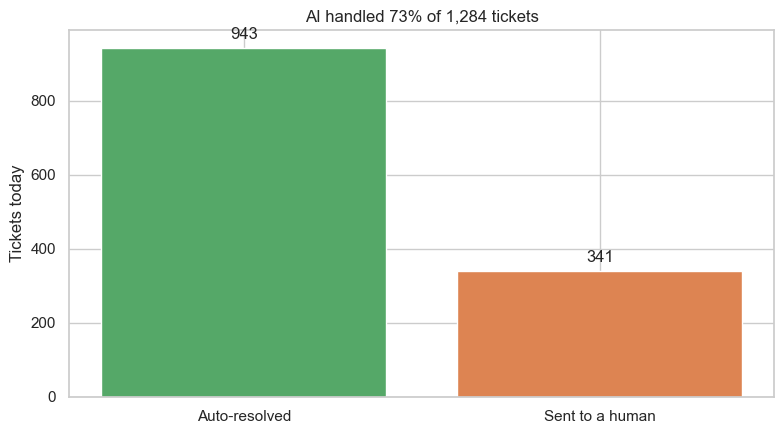

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
tickets_human = tickets_total - tickets_auto
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(["Auto-resolved", "Sent to a human"], [tickets_auto, tickets_human],
       color=['#55A868', '#DD8452'])
for i, v in enumerate([tickets_auto, tickets_human]):
    ax.text(i, v + 15, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("Tickets today")
ax.set_title(f"AI handled {auto_rate:.0%} of {tickets_total:,} tickets")
plt.tight_layout()
plt.show()


**How to read it:** the green bar is everything the AI closed on its own; the orange bar is the smaller slice a person still had to touch.

## What you just saw — and where you'll build it

| You saw | The real version lives in |
|---|---|
| AI triage of free-form text into structured tags | Module 6 — NB 22 (AI workflows), NB 25 (documents) |
| Grounded answers from your own docs (RAG) | Module 6 — NB 23; Module 7 — NB 29 |
| A business KPI snapshot / dashboard | Module 1 — NB 1; Module 2; Capstone A — NB 41 |
| Tying it all into a shipped feature | Capstone B — NB 42; Module 7 POCs |

### 🚀 Now start the journey

- **Want the *why* first?** Skim **NB 43 — Digital Transformation** (no coding) to see *why* organisations are automating with AI.
- **Ready to build skills?** Begin **Module 1 — NB 1 (Python Basics)**.
- **Tip:** set up your professional toolchain early — **NB 45 (Git, GitHub, Copilot)** pays off across every later notebook.

You'll come back to this notebook's tricks again and again — except next time, *you'll* be writing them.